# Ellipse fitting for all powers of a single particle

In [109]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
import json
import csv
import os

PX_XZ = 1/1.7625  # µm/pixel
PX_YZ = 1/1.9835  # µm/pixel
TILT_DEG = 8.368  # camera tilt (anticlockwise)

def extract_silhouette(img):
    img = cv2.GaussianBlur(img, (5,5), 0)
    bw = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 51, 5)
    bw = cv2.morphologyEx(bw, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))
    return bw

def extract_largest_contour(mask):
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    largest = max(contours, key=cv2.contourArea)
    return largest.reshape(-1,2)

def pixels_to_lab_coords(pts, px_scale):
    pts = pts.astype(float)
    x = pts[:,0] * px_scale
    z = pts[:,1] * px_scale
    return np.column_stack([x, z])

def undo_tilt_fullframe(pts, tilt_deg):
    theta = np.deg2rad(tilt_deg)
    R = np.array([[ np.cos(theta),  np.sin(theta)],
                  [-np.sin(theta),  np.cos(theta)]])
    return (R @ pts.T).T

def fit_ellipse_lab(pts):
    pts_cv = pts.astype(np.float32).reshape(-1,1,2)
    ellipse = cv2.fitEllipse(pts_cv)

    (cx, cz), (major, minor), angle = ellipse

    return {"center": (cx, cz),
            "a_or_b": major/2,
            "c": minor/2,
            "angle_deg": angle}

def process_image(img, px_scale, tilt_correction=False):
    mask = extract_silhouette(img)
    pts = extract_largest_contour(mask)

    pts_lab = pixels_to_lab_coords(pts, px_scale)

    if tilt_correction:
        pts_lab = undo_tilt_fullframe(pts_lab, TILT_DEG)

    ellipse = fit_ellipse_lab(pts_lab)
    return ellipse

def draw_overlay(ax, image, ellipse_dict, px_scale, tilt_correction):
    cx_lab, cz_lab = ellipse_dict["center"]
    a = ellipse_dict["a_or_b"]
    c = ellipse_dict["c"]
    angle_lab_deg = ellipse_dict["angle_deg"]

    if tilt_correction:
        angle_disp_deg = angle_lab_deg + TILT_DEG
        theta_ref = np.deg2rad(TILT_DEG)
    else:
        angle_disp_deg = angle_lab_deg
        theta_ref = 0.0

    theta_disp = np.deg2rad(angle_disp_deg)

    t = np.linspace(0, 2*np.pi, 600)
    x0 = a * np.cos(t)
    z0 = c * np.sin(t)

    theta_lab = np.deg2rad(angle_lab_deg)
    R_lab = np.array([[np.cos(theta_lab), -np.sin(theta_lab)],
                      [np.sin(theta_lab),  np.cos(theta_lab)]])

    pts = (R_lab @ np.vstack([x0, z0])).T
    pts[:,0] += cx_lab
    pts[:,1] += cz_lab

    # apply camera tilt back for XZ
    if tilt_correction:
        theta_cam = np.deg2rad(TILT_DEG)
        R_cam = np.array([[ np.cos(theta_cam), -np.sin(theta_cam)],
                          [ np.sin(theta_cam),  np.cos(theta_cam)]])
        pts = (R_cam @ pts.T).T

        center_lab = np.array([[cx_lab, cz_lab]])
        center_disp = (R_cam @ center_lab.T).T[0]
    else:
        center_disp = np.array([cx_lab, cz_lab])

    # pixel conversion
    cx = center_disp[0] / px_scale
    cz = center_disp[1] / px_scale
    x_px = pts[:,0] / px_scale
    z_px = pts[:,1] / px_scale

    # directions
    dx, dz = np.cos(theta_disp), np.sin(theta_disp)
    dx_ref, dz_ref = np.cos(theta_ref), np.sin(theta_ref)

    L = a / px_scale

    ax.imshow(image, cmap='gray', origin='lower')
    ax.plot(x_px, z_px, color='red', lw=1.5)

    # lab horizontal
    ref_len = L * 2
    ax.plot([cx - ref_len*dx_ref, cx + ref_len*dx_ref],
            [cz - ref_len*dz_ref, cz + ref_len*dz_ref],
            color='navy', linestyle='--', lw=1.6)

    # major axis
    ax.plot([cx - L*dx, cx + L*dx], [cz - L*dz, cz + L*dz], color='lime', lw=1.6)

    # signed physics angle
    delta = angle_disp_deg - np.rad2deg(theta_ref)
    delta = (delta + 180) % 360 - 180

    radius = L * 0.8

    if delta >= 0:
        t1, t2 = 0, delta
    else:
        t1, t2 = delta, 0

    arc = Arc((cx, cz), width=2*radius, height=2*radius, angle=np.rad2deg(theta_ref), theta1=t1, theta2=t2, color='cyan', lw=2)
    ax.add_patch(arc)
    ax.text(cx + radius*1.2, cz + radius*1.2, f"{delta:.2f}°", color='tab:purple', fontsize=12, weight='bold')

    margin = L * 5  #tight crop
    ax.set_xlim(cx - margin, cx + margin)
    ax.set_ylim(cz - margin, cz + margin)

def save_results_to_json(json_path, particle, power, ellipse_xz, ellipse_yz, scale_xz, scale_yz, tilt_deg):
    data = {"particle": particle, "power_mW": power,
    "a_um": float(ellipse_xz["a_or_b"]), "b_um": float(ellipse_yz["a_or_b"]),
    "c_xz_um": float(ellipse_xz["c"]), "c_yz_um": float(ellipse_yz["c"]),
    "c_mean_um": float(0.5*(ellipse_xz["c"] + ellipse_yz["c"])),
    "angle_xz_lab_deg": float(ellipse_xz["angle_deg"]), "angle_yz_lab_deg": float(ellipse_yz["angle_deg"]),
    "scale_xz": scale_xz, "scale_yz": scale_yz, "camera_tilt_deg": tilt_deg}
    
    os.makedirs(os.path.dirname(json_path), exist_ok=True)

    with open(json_path, "w") as f:
        json.dump(data, f, indent=4)

def append_results_to_csv(csv_path, particle, power, ellipse_xz, ellipse_yz):
    file_exists = os.path.isfile(csv_path)

    a = float(ellipse_xz["a_or_b"])
    b = float(ellipse_yz["a_or_b"])
    c_xz = float(ellipse_xz["c"])
    c_yz = float(ellipse_yz["c"])
    c_mean = 0.5 * (c_xz + c_yz)
    angle_xz = float(ellipse_xz["angle_deg"])
    angle_yz = float(ellipse_yz["angle_deg"])

    row = [particle, power, a, b, c_xz, c_yz, c_mean, angle_xz, angle_yz]
    header = ["particle", "power_mW", "a_um", "b_um", "c_xz_um", "c_yz_um", "c_mean_um", "angle_xz_deg", "angle_yz_deg"]

    with open(csv_path, "a", newline="") as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(header)
        writer.writerow(row)

def process_particle_batch(particle, PX_XZ, PX_YZ, TILT_DEG):
    POWERS = [10, 7, 5, 4, 3]
    out_loc = fr"A:\LML\Images\{particle}"
    csv_path = fr"A:\LML\Images\full_ellipsoid_data.csv"
    os.makedirs(out_loc, exist_ok=True)

    results = []

    for power in POWERS:
        print(f"\n--- Processing {particle} at {power} mW ---")

        img_xz_path = fr"{out_loc}\{particle}_xz_{power}mW.png"
        img_yz_path = fr"{out_loc}\{particle}_yz_{power}mW.png"
        json_path = fr"{out_loc}\{particle}_{power}mW_parameters.json"

        img_xz = cv2.imread(img_xz_path, 0)
        img_yz = cv2.imread(img_yz_path, 0)

        if img_xz is None or img_yz is None:
            print(f"⚠️ Missing image for {power} mW — skipping")
            continue

        img_xz = cv2.flip(img_xz, 0)
        img_yz = cv2.flip(img_yz, 0)

        ellipse_xz = process_image(img_xz, PX_XZ, tilt_correction=True)
        ellipse_yz = process_image(img_yz, PX_YZ, tilt_correction=False)

        print(f"a = {ellipse_xz['a_or_b']:.3f} µm | b = {ellipse_yz['a_or_b']:.3f} µm")
        print(f"c_xz = {ellipse_xz['c']:.3f} µm | c_yz = {ellipse_yz['c']:.3f} µm")
        print(f"θ_xz = {ellipse_xz['angle_deg']:.3f}° | θ_yz = {ellipse_yz['angle_deg']:.3f}°")

        fig1, ax1 = plt.subplots(figsize=(6,6))
        draw_overlay(ax1, img_xz, ellipse_xz, PX_XZ, True)
        ax1.set_title(f"{particle} XZ {power}mW")
        plt.savefig(fr"{out_loc}\{particle}_xz_{power}mW_overlay.png", dpi=500, bbox_inches='tight')
        plt.close(fig1)

        fig2, ax2 = plt.subplots(figsize=(6,6))
        draw_overlay(ax2, img_yz, ellipse_yz, PX_YZ, False)
        ax2.set_title(f"{particle} YZ {power}mW")
        plt.savefig(fr"{out_loc}\{particle}_yz_{power}mW_overlay.png", dpi=500, bbox_inches='tight')
        plt.close(fig2)

        save_results_to_json(json_path, particle, power, ellipse_xz, ellipse_yz, PX_XZ, PX_YZ, TILT_DEG)
        append_results_to_csv(csv_path, particle, power, ellipse_xz, ellipse_yz)

        results.append((power, img_xz, img_yz, ellipse_xz, ellipse_yz)) # store for preview

    return results

def preview_particle_results(results, PX_XZ, PX_YZ):
    if not results:
        print("No results to preview.")
        return

    n = len(results)
    fig, axs = plt.subplots(n, 2, figsize=(10, 4*n))

    if n == 1:
        axs = np.array([axs])

    for i, (power, img_xz, img_yz, exz, eyz) in enumerate(results):

        draw_overlay(axs[i,0], img_xz, exz, PX_XZ, True)
        axs[i,0].set_title(f"XZ {power} mW")

        draw_overlay(axs[i,1], img_yz, eyz, PX_YZ, False)
        axs[i,1].set_title(f"YZ {power} mW")

    plt.tight_layout()
    plt.show()



--- Processing C69 at 10 mW ---
a = 15.076 µm | b = 19.020 µm
c_xz = 22.782 µm | c_yz = 23.874 µm
θ_xz = 179.006° | θ_yz = 172.564°

--- Processing C69 at 7 mW ---
a = 16.670 µm | b = 17.156 µm
c_xz = 22.975 µm | c_yz = 24.135 µm
θ_xz = 171.225° | θ_yz = 167.587°

--- Processing C69 at 5 mW ---
a = 15.716 µm | b = 18.021 µm
c_xz = 22.982 µm | c_yz = 24.532 µm
θ_xz = 172.154° | θ_yz = 171.621°

--- Processing C69 at 4 mW ---
a = 13.056 µm | b = 20.677 µm
c_xz = 23.658 µm | c_yz = 24.515 µm
θ_xz = 177.322° | θ_yz = 167.374°

--- Processing C69 at 3 mW ---
⚠️ Missing image for 3 mW — skipping


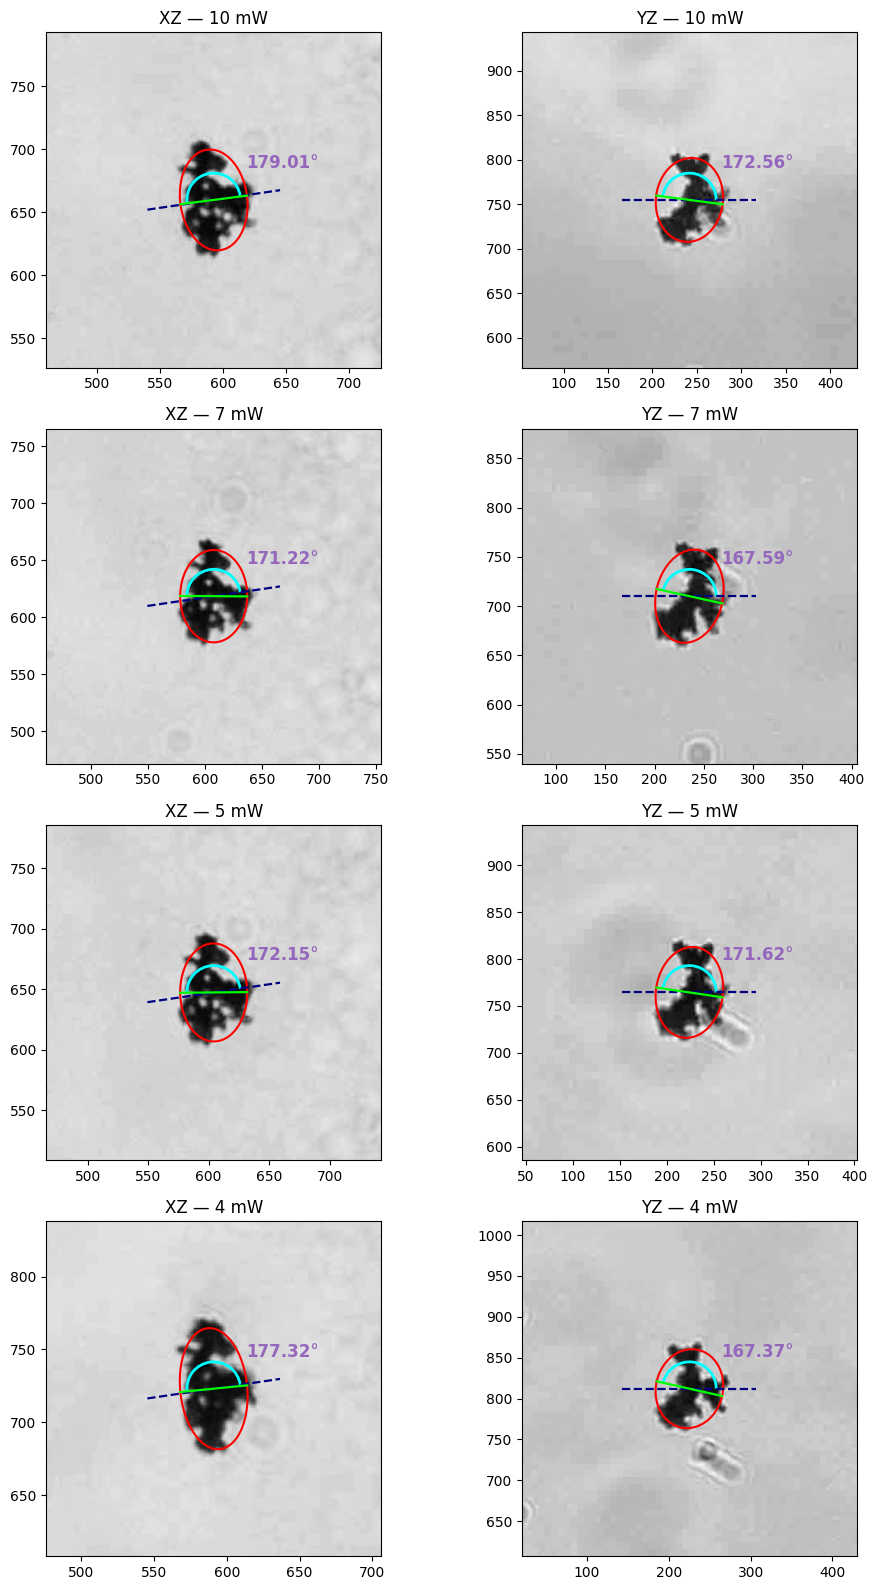

In [113]:
particle = "C69"

results = process_particle_batch(particle, PX_XZ, PX_YZ, TILT_DEG)
preview_particle_results(results, PX_XZ, PX_YZ)

## Single Power Preview; no saving

a = 14.963 µm
b = 10.093 µm
c_xz = 22.470 µm
c_yz = 22.989 µm
θ_xz = 167.865° 
θ_yz = 155.137°


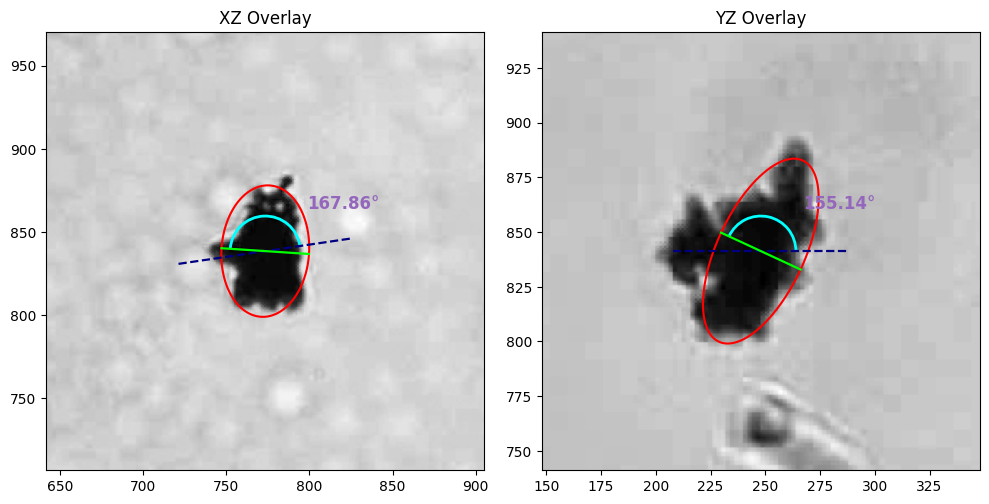

In [114]:
particle, power = "C60", 10
img_xz_path = fr"A:\LML\Images\{particle}\{particle}_xz_{power}mW.png"
img_yz_path = fr"A:\LML\Images\{particle}\{particle}_yz_{power}mW.png"
out_loc = fr"A:\LML\Images\{particle}"
csv_path = fr"A:\LML\Images\full_ellipsoid_data.csv"
json_path = fr"{out_loc}\{particle}_{power}mW_parameters.json"

os.makedirs(out_loc, exist_ok=True)

img_xz = cv2.imread(img_xz_path, 0)
img_yz = cv2.imread(img_yz_path, 0)

# vertical flip so origin is bottom-left
img_xz = cv2.flip(img_xz, 0)
img_yz = cv2.flip(img_yz, 0)

ellipse_xz = process_image(img_xz, PX_XZ, tilt_correction=True)
ellipse_yz = process_image(img_yz, PX_YZ, tilt_correction=False)

print(f"a = {ellipse_xz['a_or_b']:.3f} µm\nb = {ellipse_yz['a_or_b']:.3f} µm")
print(f"c_xz = {ellipse_xz['c']:.3f} µm\nc_yz = {ellipse_yz['c']:.3f} µm")
print(f"θ_xz = {ellipse_xz['angle_deg']:.3f}° \nθ_yz = {ellipse_yz['angle_deg']:.3f}°")
'''
fig1, ax1 = plt.subplots(figsize=(6,6))
draw_overlay(ax1, img_xz, ellipse_xz, PX_XZ, True)
ax1.set_title(f"{particle} XZ-Projection {power}mW")
plt.savefig(fr"{out_loc}\{particle}_xz_{power}mW_overlay.png", dpi=500, bbox_inches='tight')
plt.close(fig1)

fig2, ax2 = plt.subplots(figsize=(6,6))
draw_overlay(ax2, img_yz, ellipse_yz, PX_YZ, False)
ax2.set_title(f"{particle} YZ-Projection {power}mW")
plt.savefig(fr"{out_loc}\{particle}_yz_{power}mW_overlay.png", dpi=500, bbox_inches='tight')
plt.close(fig2)
'''
fig, axs = plt.subplots(1,2, figsize=(10,5))

draw_overlay(axs[0], img_xz, ellipse_xz, PX_XZ, True)
axs[0].set_title("XZ Overlay")

draw_overlay(axs[1], img_yz, ellipse_yz, PX_YZ, False)
axs[1].set_title("YZ Overlay")

plt.tight_layout()
plt.show()

#save_results_to_json(json_path, particle, power, ellipse_xz, ellipse_yz, PX_XZ, PX_YZ, TILT_DEG)
#append_results_to_csv(csv_path, particle, power, ellipse_xz, ellipse_yz)
#print(f"\nParameters saved to: {json_path}\nParameters appended to: {csv_path}")

## Ellipsoid reconstruction to verify

Loaded parameters:
a = 14.957 µm
b = 13.969 µm
c = 22.098 µm
theta_xz = 163.659°
theta_yz = 155.861°

Reconstructed c-axis (lab frame):
[-0.25846219 -0.39506208  0.88154594]


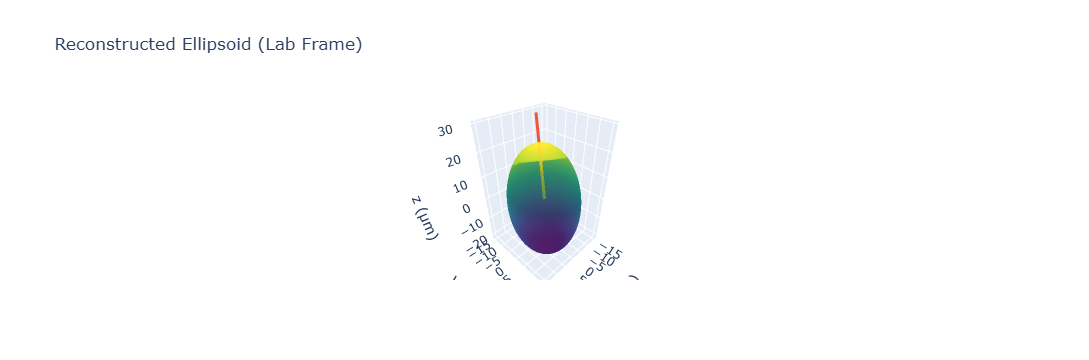

In [72]:
import numpy as np
import json
import plotly.graph_objects as go

json_path = fr"A:\LML\Images\{particle}\parameters.json"

with open(json_path, "r") as f:
    params = json.load(f)

a = params["a_um"]
b = params["b_um"]
c = params["c_mean_um"]

theta_xz = params["angle_xz_lab_deg"]
theta_yz = params["angle_yz_lab_deg"]

print("Loaded parameters:")
print(f"a = {a:.3f} µm")
print(f"b = {b:.3f} µm")
print(f"c = {c:.3f} µm")
print(f"theta_xz = {theta_xz:.3f}°")
print(f"theta_yz = {theta_yz:.3f}°")


def wrap_signed(angle_deg):
    return (angle_deg + 180) % 360 - 180

theta_xz = wrap_signed(theta_xz)
theta_yz = wrap_signed(theta_yz)

def reconstruct_c_axis(theta_xz_deg, theta_yz_deg):
    """ Correct reconstruction consistent with OpenCV ellipse angles.
    Works when major axis ≈ c."""

    tx = np.deg2rad(theta_xz_deg)
    ty = np.deg2rad(theta_yz_deg)

    # Use tangent relations
    cx = np.tan(tx)
    cy = np.tan(ty)
    cz = 1.0

    vec = np.array([cx, cy, cz])
    vec = vec / np.linalg.norm(vec)

    return vec

c_hat = reconstruct_c_axis(theta_xz, theta_yz)

print("\nReconstructed c-axis (lab frame):")
print(c_hat)

def rotation_from_z(vec):
    """ Returns rotation matrix that maps local z-axis to vec.
    Uses Rodrigues formula."""

    z_axis = np.array([0.0, 0.0, 1.0])
    v = vec / np.linalg.norm(vec)

    cross = np.cross(z_axis, v)
    s = np.linalg.norm(cross)
    c = np.dot(z_axis, v)

    if s < 1e-10:
        return np.eye(3)

    vx = np.array([[0, -cross[2], cross[1]],
                   [cross[2], 0, -cross[0]],
                   [-cross[1], cross[0], 0]])

    R = np.eye(3) + vx + vx @ vx * ((1 - c) / (s**2))
    return R

R = rotation_from_z(c_hat)

def generate_ellipsoid(a, b, c, n=120):

    u = np.linspace(0, np.pi, n)
    v = np.linspace(0, 2*np.pi, n)
    u, v = np.meshgrid(u, v)

    x = a * np.sin(u) * np.cos(v)
    y = b * np.sin(u) * np.sin(v)
    z = c * np.cos(u)

    pts = np.stack([x, y, z], axis=-1)
    return pts

ellipsoid_pts = generate_ellipsoid(a, b, c)

def rotate_points(pts, R): #Rotate into lab frame
    shape = pts.shape
    pts_flat = pts.reshape(-1, 3)
    pts_rot = (R @ pts_flat.T).T
    return pts_rot.reshape(shape)

ellipsoid_lab = rotate_points(ellipsoid_pts, R)

X = ellipsoid_lab[..., 0]
Y = ellipsoid_lab[..., 1]
Z = ellipsoid_lab[..., 2]

fig = go.Figure()

fig.add_surface(x=X, y=Y, z=Z, colorscale="Viridis", opacity=0.85, showscale=False)

# also draw c-axis vector for sanity
origin = np.array([0, 0, 0])
axis_len = max(a, b, c) * 1.5

fig.add_trace(go.Scatter3d(x=[0, c_hat[0]*axis_len], y=[0, c_hat[1]*axis_len], z=[0, c_hat[2]*axis_len], 
                           mode="lines", line=dict(width=6), name="c-axis"))

fig.update_layout(title="Reconstructed Ellipsoid (Lab Frame)", 
                  scene=dict(xaxis_title="x (µm)", yaxis_title="y (µm)", zaxis_title="z (µm)", aspectmode="data"))

fig.show()
